In [1]:
!pip install gymnasium[classic-control]
!pip install gymnasium[box2d]
!pip install stable-baselines3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 118.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 60.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 78.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.5/187.5 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 952.1/952.1 kB 42.0 MB/s eta 0:00:00
  Attempting uninstall: gymnasium
    Found existing installation: gymnasium 1.3.0
    Uninstalling gymnasium-1.3.0:
      Successfully uninstalled gymnasium-1.3.0


In [2]:
import collections
import random
import time

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import gymnasium as gym

from stable_baselines3 import PPO
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.monitor import Monitor

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

device: cuda


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [3]:
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

In [4]:
env = gym.make("CartPole-v1")

obs, _ = env.reset(seed=42)

print("Observation space:", env.observation_space)
print("Action space:", env.action_space)
print("Initial observation:", obs)

Observation space: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
Action space: Discrete(2)
Initial observation: [ 0.0273956  -0.00611216  0.03585979  0.0197368 ]


In [5]:
env = gym.make("CartPole-v1")

obs, _ = env.reset(seed=42)

done = False
total_reward = 0

while not done:
    action = env.action_space.sample()

    next_obs, reward, terminated, truncated, _ = env.step(action)

    done = terminated or truncated

    total_reward += reward
    obs = next_obs

print("Random agent total reward:", total_reward)

Random agent total reward: 14.0


In [6]:
class QNet(nn.Module):
    def __init__(self, obs_dim, act_dim):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(obs_dim, 128),
            nn.ReLU(),

            nn.Linear(128, 128),
            nn.ReLU(),

            nn.Linear(128, act_dim)
        )

    def forward(self, x):
        return self.net(x)

In [7]:
class ReplayBuffer:
    def __init__(self, capacity=50_000):
        self.buffer = collections.deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)

        states, actions, rewards, next_states, dones = zip(*batch)

        return (
            np.array(states),
            np.array(actions),
            np.array(rewards),
            np.array(next_states),
            np.array(dones)
        )

    def __len__(self):
        return len(self.buffer)

In [8]:
env = gym.make("CartPole-v1")

obs_dim = env.observation_space.shape[0]
act_dim = env.action_space.n

q_net = QNet(obs_dim, act_dim).to(device)
target_net = QNet(obs_dim, act_dim).to(device)

# Copy weights initially
target_net.load_state_dict(q_net.state_dict())

target_net.eval()

optimizer = optim.Adam(q_net.parameters(), lr=1e-3)

buffer = ReplayBuffer()

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [9]:
batch_size = 64
gamma = 0.99

epsilon_start = 1.0
epsilon_end = 0.05
epsilon_decay_steps = 5000

sync_target_every = 1000

train_after = 1000

total_steps = 30_000

In [10]:
env = gym.make("CartPole-v1")

obs, _ = env.reset(seed=42)

step_count = 0

episode_rewards = []
episode_reward = 0

start_time = time.perf_counter()

while step_count < total_steps:

    # Linear epsilon decay
    epsilon = max(
        epsilon_end,
        epsilon_start - (epsilon_start - epsilon_end) * step_count / epsilon_decay_steps
    )

    # Epsilon-greedy action
    if random.random() < epsilon:
        action = env.action_space.sample()
    else:
         with torch.no_grad():
            state_tensor = torch.tensor(obs, dtype=torch.float32).unsqueeze(0).to(device)
            q_values = q_net(state_tensor)
            action = q_values.argmax(dim=1).item()

    next_obs, reward, terminated, truncated, _ = env.step(action)

    done = terminated or truncated

    buffer.push(obs, action, reward, next_obs, done)

    obs = next_obs

    episode_reward += reward
    step_count += 1

     # Training step
    if len(buffer) >= train_after:

        states, actions, rewards, next_states, dones = buffer.sample(batch_size)

        states = torch.tensor(states, dtype=torch.float32).to(device)
        actions = torch.tensor(actions, dtype=torch.int64).unsqueeze(1).to(device)
        rewards = torch.tensor(rewards, dtype=torch.float32).unsqueeze(1).to(device)
        next_states = torch.tensor(next_states, dtype=torch.float32).to(device)
        dones = torch.tensor(dones, dtype=torch.float32).unsqueeze(1).to(device)

        # Current Q values
        current_q = q_net(states).gather(1, actions)
        # Target Q values
        with torch.no_grad():
            max_next_q = target_net(next_states).max(dim=1, keepdim=True)[0]
            target_q = rewards + gamma * max_next_q * (1 - dones)

        loss = nn.MSELoss()(current_q, target_q)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # Sync target network
    if step_count % sync_target_every == 0:
        target_net.load_state_dict(q_net.state_dict())

    if done:
        episode_rewards.append(episode_reward)

        obs, _ = env.reset()
        episode_reward = 0

end_time = time.perf_counter()
dqn_train_time = end_time - start_time

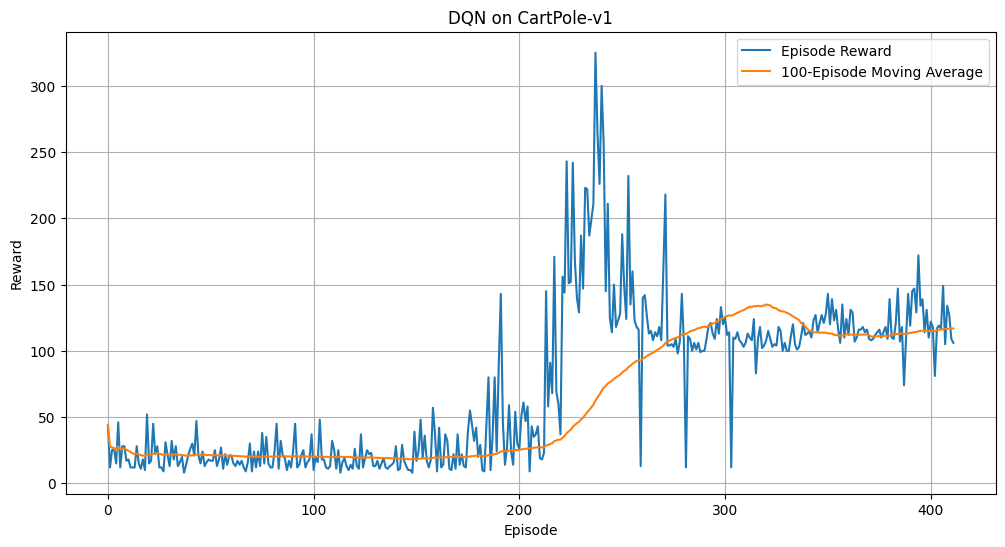

In [11]:
moving_avg = []
window = 100

for i in range(len(episode_rewards)):
    start = max(0, i - window + 1)
    moving_avg.append(np.mean(episode_rewards[start:i+1]))

plt.figure(figsize=(12, 6))

plt.plot(episode_rewards, label="Episode Reward")
plt.plot(moving_avg, label="100-Episode Moving Average")

plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("DQN on CartPole-v1")
plt.legend()
plt.grid()
plt.show()

In [12]:
avg_last_100 = np.mean(episode_rewards[-100:])

print("Average reward over last 100 episodes:", avg_last_100)
print(f"Training time: {dqn_train_time:.2f} seconds")

Average reward over last 100 episodes: 116.81
Training time: 73.41 seconds


In [13]:
cartpole_env = Monitor(gym.make("CartPole-v1"))

ppo_cartpole = PPO(
    "MlpPolicy",
    cartpole_env,
    verbose=0,
    seed=42
)


t0 = time.perf_counter()

ppo_cartpole.learn(total_timesteps=50_000)

cartpole_train_time = time.perf_counter() - t0

/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


In [14]:
mean_reward, std_reward = evaluate_policy(
    ppo_cartpole,
    cartpole_env,
    n_eval_episodes=20
)

print(
    f"PPO CartPole: {mean_reward:.1f} ± {std_reward:.1f} "
    f"over 20 episodes (trained in {cartpole_train_time:.0f}s)"
)

PPO CartPole: 500.0 ± 0.0 over 20 episodes (trained in 112s)


In [16]:
ll_env = Monitor(gym.make("LunarLander-v3"))

ppo_ll = PPO(
    "MlpPolicy",
    ll_env,
    verbose=0,
    seed=42
)


t0 = time.perf_counter()

ppo_ll.learn(total_timesteps=300_000)

ll_train_time = time.perf_counter() - t0

<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type SwigPyPacked has no __module__ attribute
<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type SwigPyObject has no __module__ attribute
<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type swigvarlink has no __module__ attribute


In [18]:
cartpole_rewards = cartpole_env.get_episode_rewards()
ll_rewards = ll_env.get_episode_rewards()

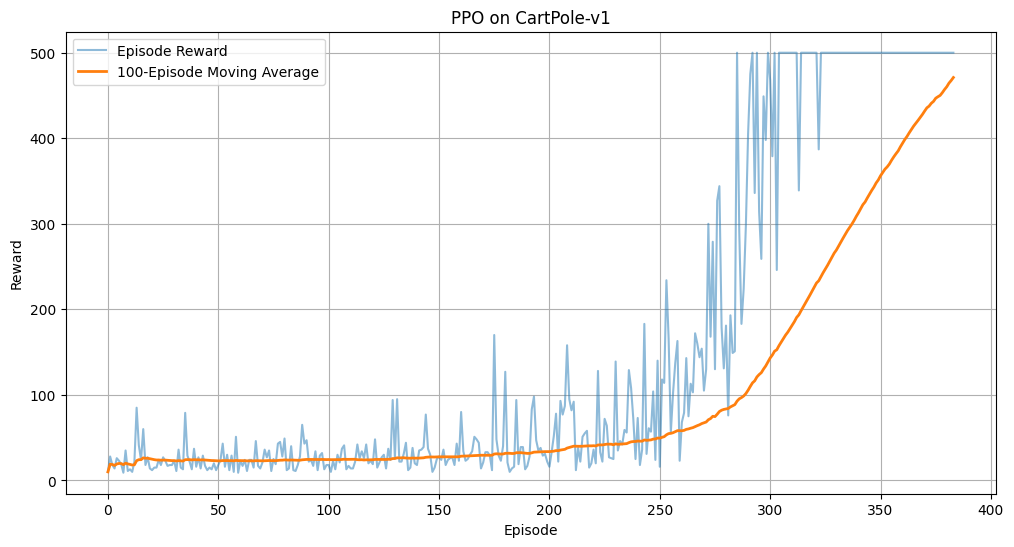

In [19]:
window = 100

cartpole_ma = []

for i in range(len(cartpole_rewards)):
    start = max(0, i - window + 1)
    cartpole_ma.append(np.mean(cartpole_rewards[start:i+1]))

plt.figure(figsize=(12, 6))

plt.plot(cartpole_rewards, alpha=0.5, label="Episode Reward")
plt.plot(cartpole_ma, linewidth=2, label="100-Episode Moving Average")

plt.title("PPO on CartPole-v1")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.legend()
plt.grid()
plt.show()

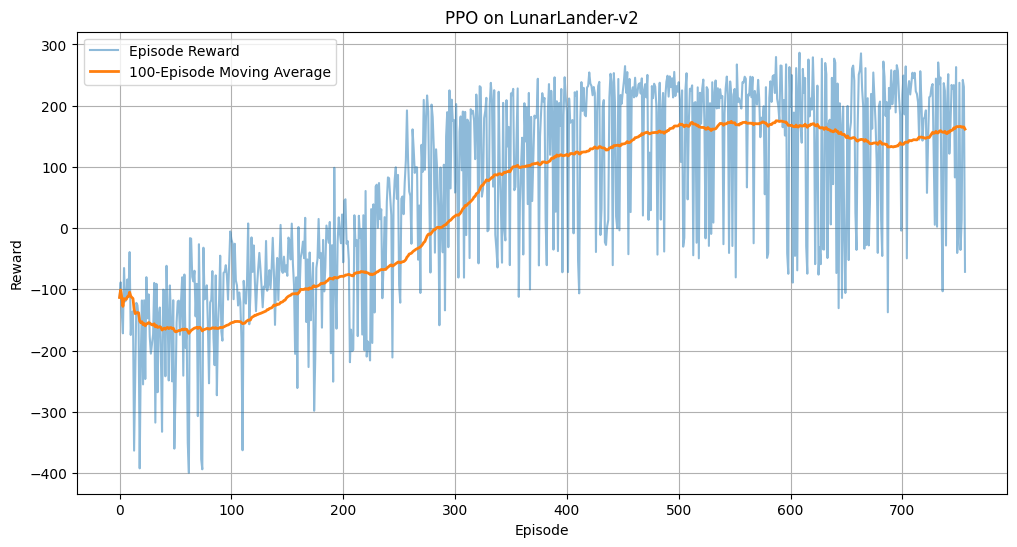

In [20]:
ll_ma = []

for i in range(len(ll_rewards)):
    start = max(0, i - window + 1)
    ll_ma.append(np.mean(ll_rewards[start:i+1]))

plt.figure(figsize=(12, 6))

plt.plot(ll_rewards, alpha=0.5, label="Episode Reward")
plt.plot(ll_ma, linewidth=2, label="100-Episode Moving Average")

plt.title("PPO on LunarLander-v2")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.legend()
plt.grid()
plt.show()